In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "E:/icu_project/models/test_predictions.csv"
)

print(df.head())
print("Total patients:", len(df))

   predicted_probability  true_label
0               0.028328         0.0
1               0.713363         0.0
2               0.018817         0.0
3               0.225931         0.0
4               0.508967         0.0
Total patients: 2400


In [2]:
def risk_category(p):

    if p < 0.25:
        return "Low"

    elif p < 0.50:
        return "Moderate"

    elif p < 0.75:
        return "High"

    else:
        return "Critical"


df["risk_group"] = df["predicted_probability"].apply(risk_category)

df.head()

,predicted_probability,true_label,risk_group
0,0.028328,0.0,Low
1,0.713363,0.0,High
2,0.018817,0.0,Low
3,0.225931,0.0,Low
4,0.508967,0.0,High


In [3]:
df["risk_group"].value_counts()

risk_group
Low         1401
Moderate     423
High         402
Critical     174
Name: count, dtype: int64

In [4]:
df.groupby("risk_group")["true_label"].mean()

risk_group
Critical    0.580460
High        0.286070
Low         0.039971
Moderate    0.163121
Name: true_label, dtype: float64

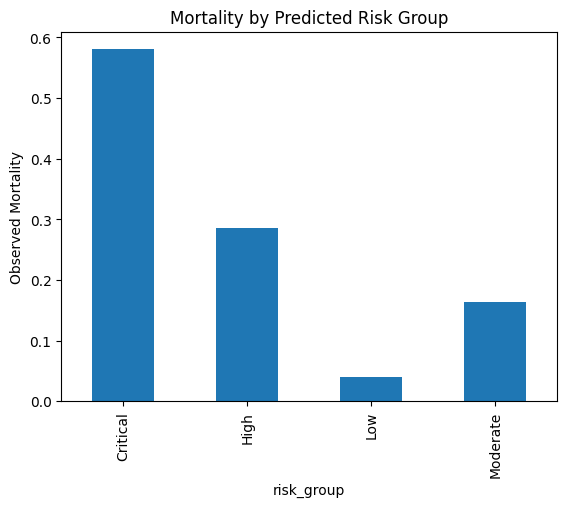

In [5]:
df.groupby("risk_group")["true_label"].mean().plot(kind="bar")

plt.ylabel("Observed Mortality")
plt.title("Mortality by Predicted Risk Group")

plt.show()

In [6]:
df.to_csv(
    "E:/icu_project/models/risk_stratification_results.csv",
    index=False
)